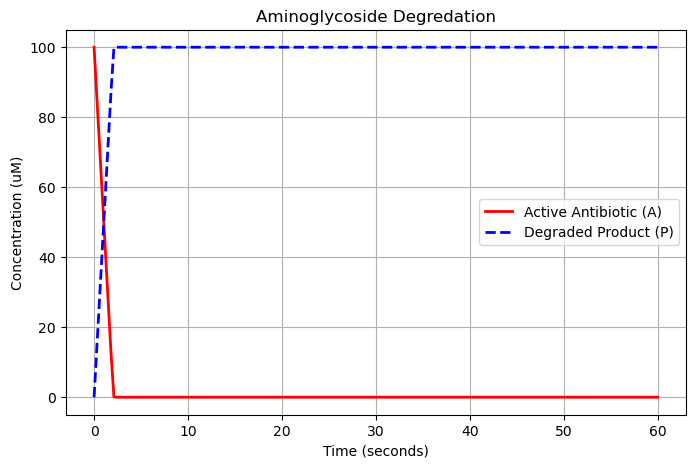

<Figure size 640x480 with 0 Axes>

In [3]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parameters
K_cat = 7000
enzyme_amount = 0.007
Vmax = K_cat * enzyme_amount
Km = 0.5
A_0 = 100.0 
T = 60       

# Time points
t = np.linspace(0, T, 200)

# Differential Equation 
def degradation_0D(A, t):
    # A cannot drop below 0
    A = max(A, 0) 
    
    # Michaelis-Menten Equation
    rate_of_degradation = (Vmax * A) / (Km + A)
    
    # Rate is negative because the antibiotic is disappearing
    dAdt = -rate_of_degradation 
    return dAdt

# Solve for Equation 
A_solution = odeint(degradation_0D, A_0, t).flatten()

# Degraded Product (P) is whatever is missing from the initial amount.
P_solution = A_0 - A_solution

# plotting results
plt.figure(figsize=(8, 5))
plt.plot(t, A_solution, label="Active Antibiotic (A)", color='red', linewidth=2)
plt.plot(t, P_solution, label="Degraded Product (P)", color='blue', linestyle="--", linewidth=2)

# labelling the graph 
plt.title("Aminoglycoside Degredation") 

plt.xlabel("Time (seconds)")
plt.ylabel("Concentration (uM)")
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("hydrogel-diff-model", dpi=300)